In [12]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)

df["target"] = data.target

print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [13]:
print("Shape:", df.shape)

Shape: (569, 31)


In [14]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Distribution:")
print(df["target"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features and target
X = df.drop("target", axis=1)
y = df["target"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Standardization
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (455, 30)
Testing data: (114, 30)


In [16]:
from sklearn.linear_model import LogisticRegression

# Create model
model = LogisticRegression(max_iter=1000)

# Train model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [17]:
# Predict classes
y_pred = model.predict(X_test)

# Predict probabilities
y_prob = model.predict_proba(X_test)[:, 1]

print("Predicted Classes:")
print(y_pred)

print("\nPredicted Probabilities:")
print(y_prob)

Predicted Classes:
[0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 0 0 1
 1 1 0 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 1 1 0
 0 0 0 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 1 0 1
 0 1 1]

Predicted Probabilities:
[5.88824186e-08 9.99988665e-01 6.41082462e-03 5.33508537e-01
 6.52500097e-10 9.92160398e-01 9.99982825e-01 5.63527494e-07
 5.43163692e-05 8.04184941e-11 9.89178556e-01 1.33241870e-03
 9.98703777e-01 2.60592467e-05 2.76224627e-04 9.01632354e-01
 3.65861856e-01 8.34997650e-01 9.99966119e-01 9.83017335e-01
 1.65771925e-03 5.17399797e-02 9.99807885e-01 9.99123324e-01
 9.90010217e-01 8.67468162e-01 4.83595669e-09 9.90463784e-01
 9.99169881e-01 9.98922169e-01 9.91912973e-01 9.99989143e-01
 9.83527366e-01 9.69239080e-01 5.37502995e-06 1.87989311e-01
 9.98451407e-01 9.71053325e-01 6.21262609e-01 5.44264495e-06
 9.99944641e-01 9.99846730e-01 9.93536689e-01 2.63830968e-08
 1.71221909e-03 7.07218502e-01 9.99998944e-01 9.998

In [18]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, roc_auc_score

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)

print("Confusion Matrix:")
print(cm)

print("\nPrecision:", precision)
print("Recall:", recall)
print("ROC-AUC:", roc_auc)

Confusion Matrix:
[[41  1]
 [ 1 71]]

Precision: 0.9861111111111112
Recall: 0.9861111111111112
ROC-AUC: 0.9953703703703703


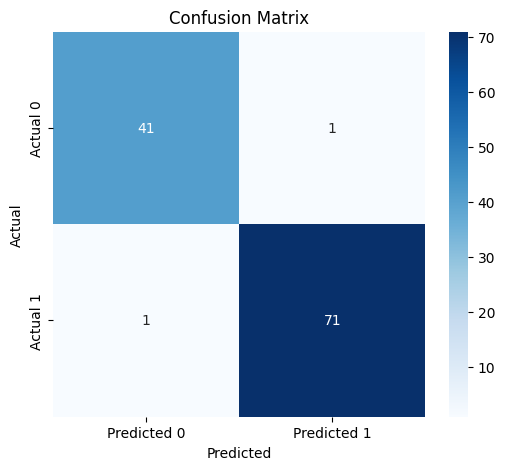

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0", "Actual 1"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

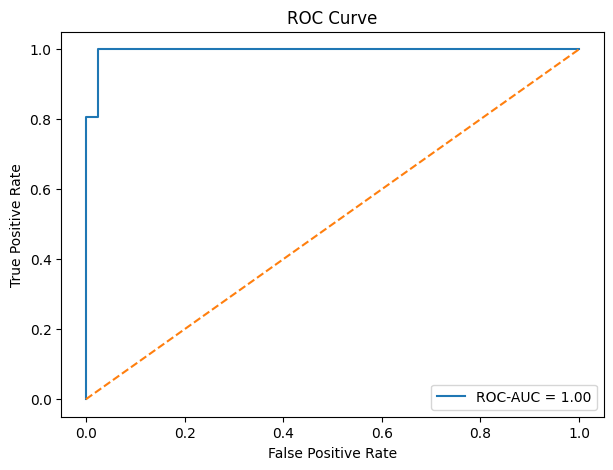

In [20]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
auc = roc_auc_score(y_test, y_prob)

# Plot ROC Curve
plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"ROC-AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

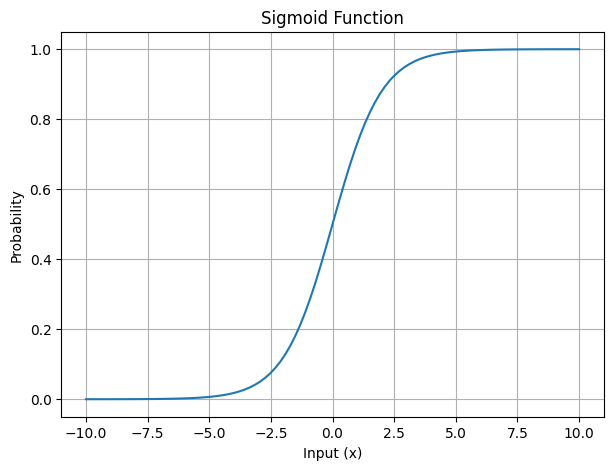

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Sigmoid function
x = np.linspace(-10, 10, 100)

y = 1 / (1 + np.exp(-x))

plt.figure(figsize=(7, 5))
plt.plot(x, y)

plt.title("Sigmoid Function")
plt.xlabel("Input (x)")
plt.ylabel("Probability")
plt.grid()
plt.show()

In [22]:
from sklearn.metrics import precision_score, recall_score

# Change threshold
threshold = 0.4

# Convert probabilities into classes
y_pred_new = (y_prob >= threshold).astype(int)

# Calculate metrics
precision_new = precision_score(y_test, y_pred_new)
recall_new = recall_score(y_test, y_pred_new)

print("Threshold:", threshold)
print("Precision:", precision_new)
print("Recall:", recall_new)

Threshold: 0.4
Precision: 0.9861111111111112
Recall: 0.9861111111111112


In [23]:
## Findings

#- Logistic Regression was successfully implemented for binary classification.
#- The dataset was divided into training and testing sets.
#- Features were standardized using StandardScaler.
#- The model was evaluated using Confusion Matrix, Precision, Recall, and ROC-AUC.
#- The Sigmoid Function was used to convert model output into probabilities.
#- Changing the classification threshold affected the Precision and Recall values.
#- Overall, Logistic Regression performed well for binary classification on the selected dataset.